In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display
from matplotlib.patches import Patch

In [18]:
# Loading the dataset
df_data=pd.read_csv('../data/processed/cleaned_data.csv',parse_dates=['Date'], date_format='%Y-%m-%d')
df=pd.DataFrame(df_data)
df.head(5)

,Date,Ticker,Company,Sector,Open,High,Low,Close,Volume,daily_return,year,month,day_of_week
0,2021-05-21,ADANIENT.NS,Adani Enterprises,Conglomerate,1316.801359,1332.762587,1296.899750,1311.913208,8314215,NaN,2021,5,4
1,2021-05-24,ADANIENT.NS,Adani Enterprises,Conglomerate,1318.497220,1325.430452,1299.842582,1303.633423,7913411,-0.006311,2021,5,0
2,2021-05-25,ADANIENT.NS,Adani Enterprises,Conglomerate,1311.165003,1318.796490,1269.815495,1279.641602,3697062,-0.018404,2021,5,1
3,2021-05-26,ADANIENT.NS,Adani Enterprises,Conglomerate,1285.826652,1323.634840,1251.210784,1319.594727,5630730,0.031222,2021,5,2
4,2021-05-27,ADANIENT.NS,Adani Enterprises,Conglomerate,1326.278388,1338.748098,1301.089573,1322.587402,36690935,0.002268,2021,5,3


In [19]:
# Basic satistics for each stock

result=[]


for ticker in df['Ticker'].unique():
    ticker_data=df[df['Ticker']==ticker]
    ticker_data=ticker_data.sort_values(by='Date')
    first_price=ticker_data['Close'].iloc[0]
    last_price=ticker_data['Close'].iloc[-1]
    total_days=ticker_data['Date'].count()
    total_return=((last_price-first_price)/first_price)*100
    result.append({
        "Ticker":ticker,
        "First_Price":first_price,
        "Last_price":last_price,
        "Trade_days":total_days,
        "Total_return":round(total_return,2)
    })

stock_summary=pd.DataFrame(result)

#sorting by total returns
stock_summary=stock_summary.sort_values(by='Total_return',ascending=False)
stockk_summary=stock_summary.reset_index(drop=True)

In [20]:
stock_summary

,Ticker,First_Price,Last_price,Trade_days,Total_return
8,BEL.NS,49.181618,406.500000,1254,726.53
12,COALINDIA.NS,97.122635,443.500000,1254,356.64
30,M&M.NS,781.275635,3042.899902,1254,289.48
33,NTPC.NS,94.057663,353.899994,1254,276.26
9,BHARTIARTL.NS,509.365875,1822.500000,1254,257.80
39,SHRIRAMFIN.NS,271.119751,954.950012,1254,252.22
47,TRENT.NS,822.467896,2755.300049,1254,235.00
15,EICHERMOT.NS,2404.764160,7312.000000,1254,204.06
34,ONGC.NS,82.523567,246.199997,1254,198.34
35,POWERGRID.NS,99.106628,284.799988,1254,187.37


In [21]:
# top and bottom 10 stocks based on total return over 5 years

top_10=stock_summary.head(10)
bottom_10=stock_summary.tail(10)

top_bottom=pd.DataFrame(pd.concat([top_10,bottom_10],ignore_index=True))
top_bottom=top_bottom.sort_values(by='Total_return',ascending=False).reset_index(drop=True)
colors=['green' if x>0 else 'red' for x in top_bottom['Total_return']]

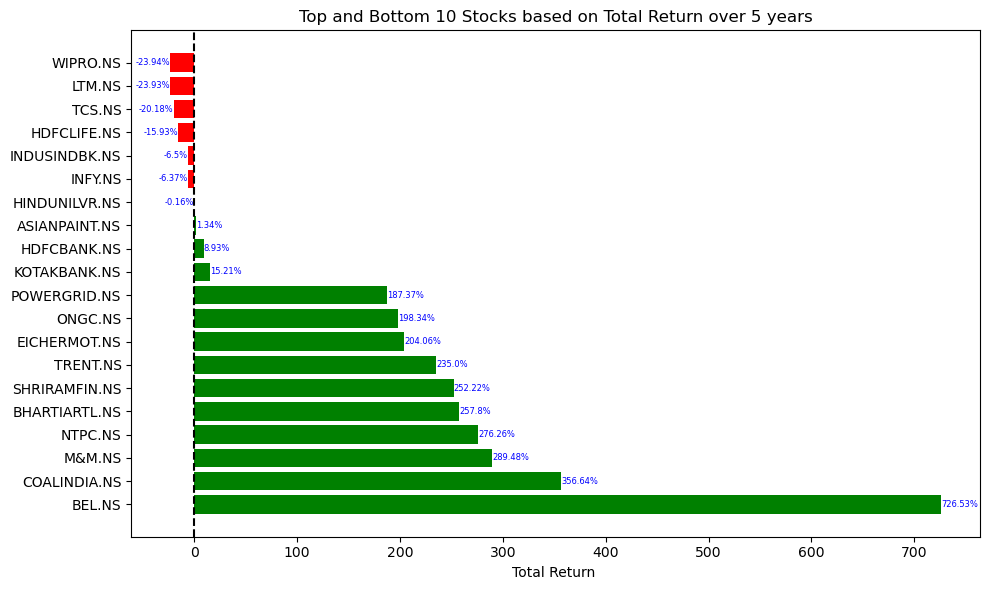

In [22]:
#CHART 1
#horizontal bar chart for top and bottom 10 stocks

plt.figure(figsize=(10,6))

plt.barh(y=top_bottom['Ticker'],width=top_bottom['Total_return'],color=colors)

plt.xlabel('Total Return ')
plt.title('Top and Bottom 10 Stocks based on Total Return over 5 years')
plt.axvline(x=0,color='black',linestyle='--')
plt.tight_layout()

for index,value in enumerate(top_bottom['Total_return']):
    plt.text(value,index,f'{value}%',va='center',ha='left' if value>0 else 'right',color='blue', size=6)

plt.show()

In [23]:
# CHART 2 
## STOCK ANALYSIS FOR EACH STOCK

#Dropdown menu
dropdown=widgets.Dropdown(
    options=sorted(df['Ticker'].unique()),
    value='TCS.NS',
    description='Select Stock:',
)

# Create a function that plots based on selected ticker

def plot_stock(ticker):
    ticker_data=df[df['Ticker']==ticker]
    ticker_data=ticker_data.sort_values(by='Date')

    ticker_data['MA20']=ticker_data['Close'].rolling(window=20).mean()
    ticker_data['MA200']=ticker_data['Close'].rolling(window=200).mean()

    #ploting
    plt.figure(figsize=(14,6))
    plt.plot(ticker_data['Date'],ticker_data['Close'],color='blue',label='Close Price',linewidth=1.5)
    plt.plot(ticker_data['Date'],ticker_data['MA20'],color='orange',label='20-day MA',linewidth=1.5)
    plt.plot(ticker_data['Date'],ticker_data['MA200'],color='red',label='200-day MA',linewidth=2)

    plt.title(f"{ticker} - price with Moving Averages")
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True,alpha=0.3)
    plt.tight_layout()
    plt.show()

# Connect dropdown to function
widgets.interact(plot_stock,ticker=dropdown)

interactive(children=(Dropdown(description='Select Stock:', index=43, options=('ADANIENT.NS', 'ADANIPORTS.NS',…

<function __main__.plot_stock(ticker)>

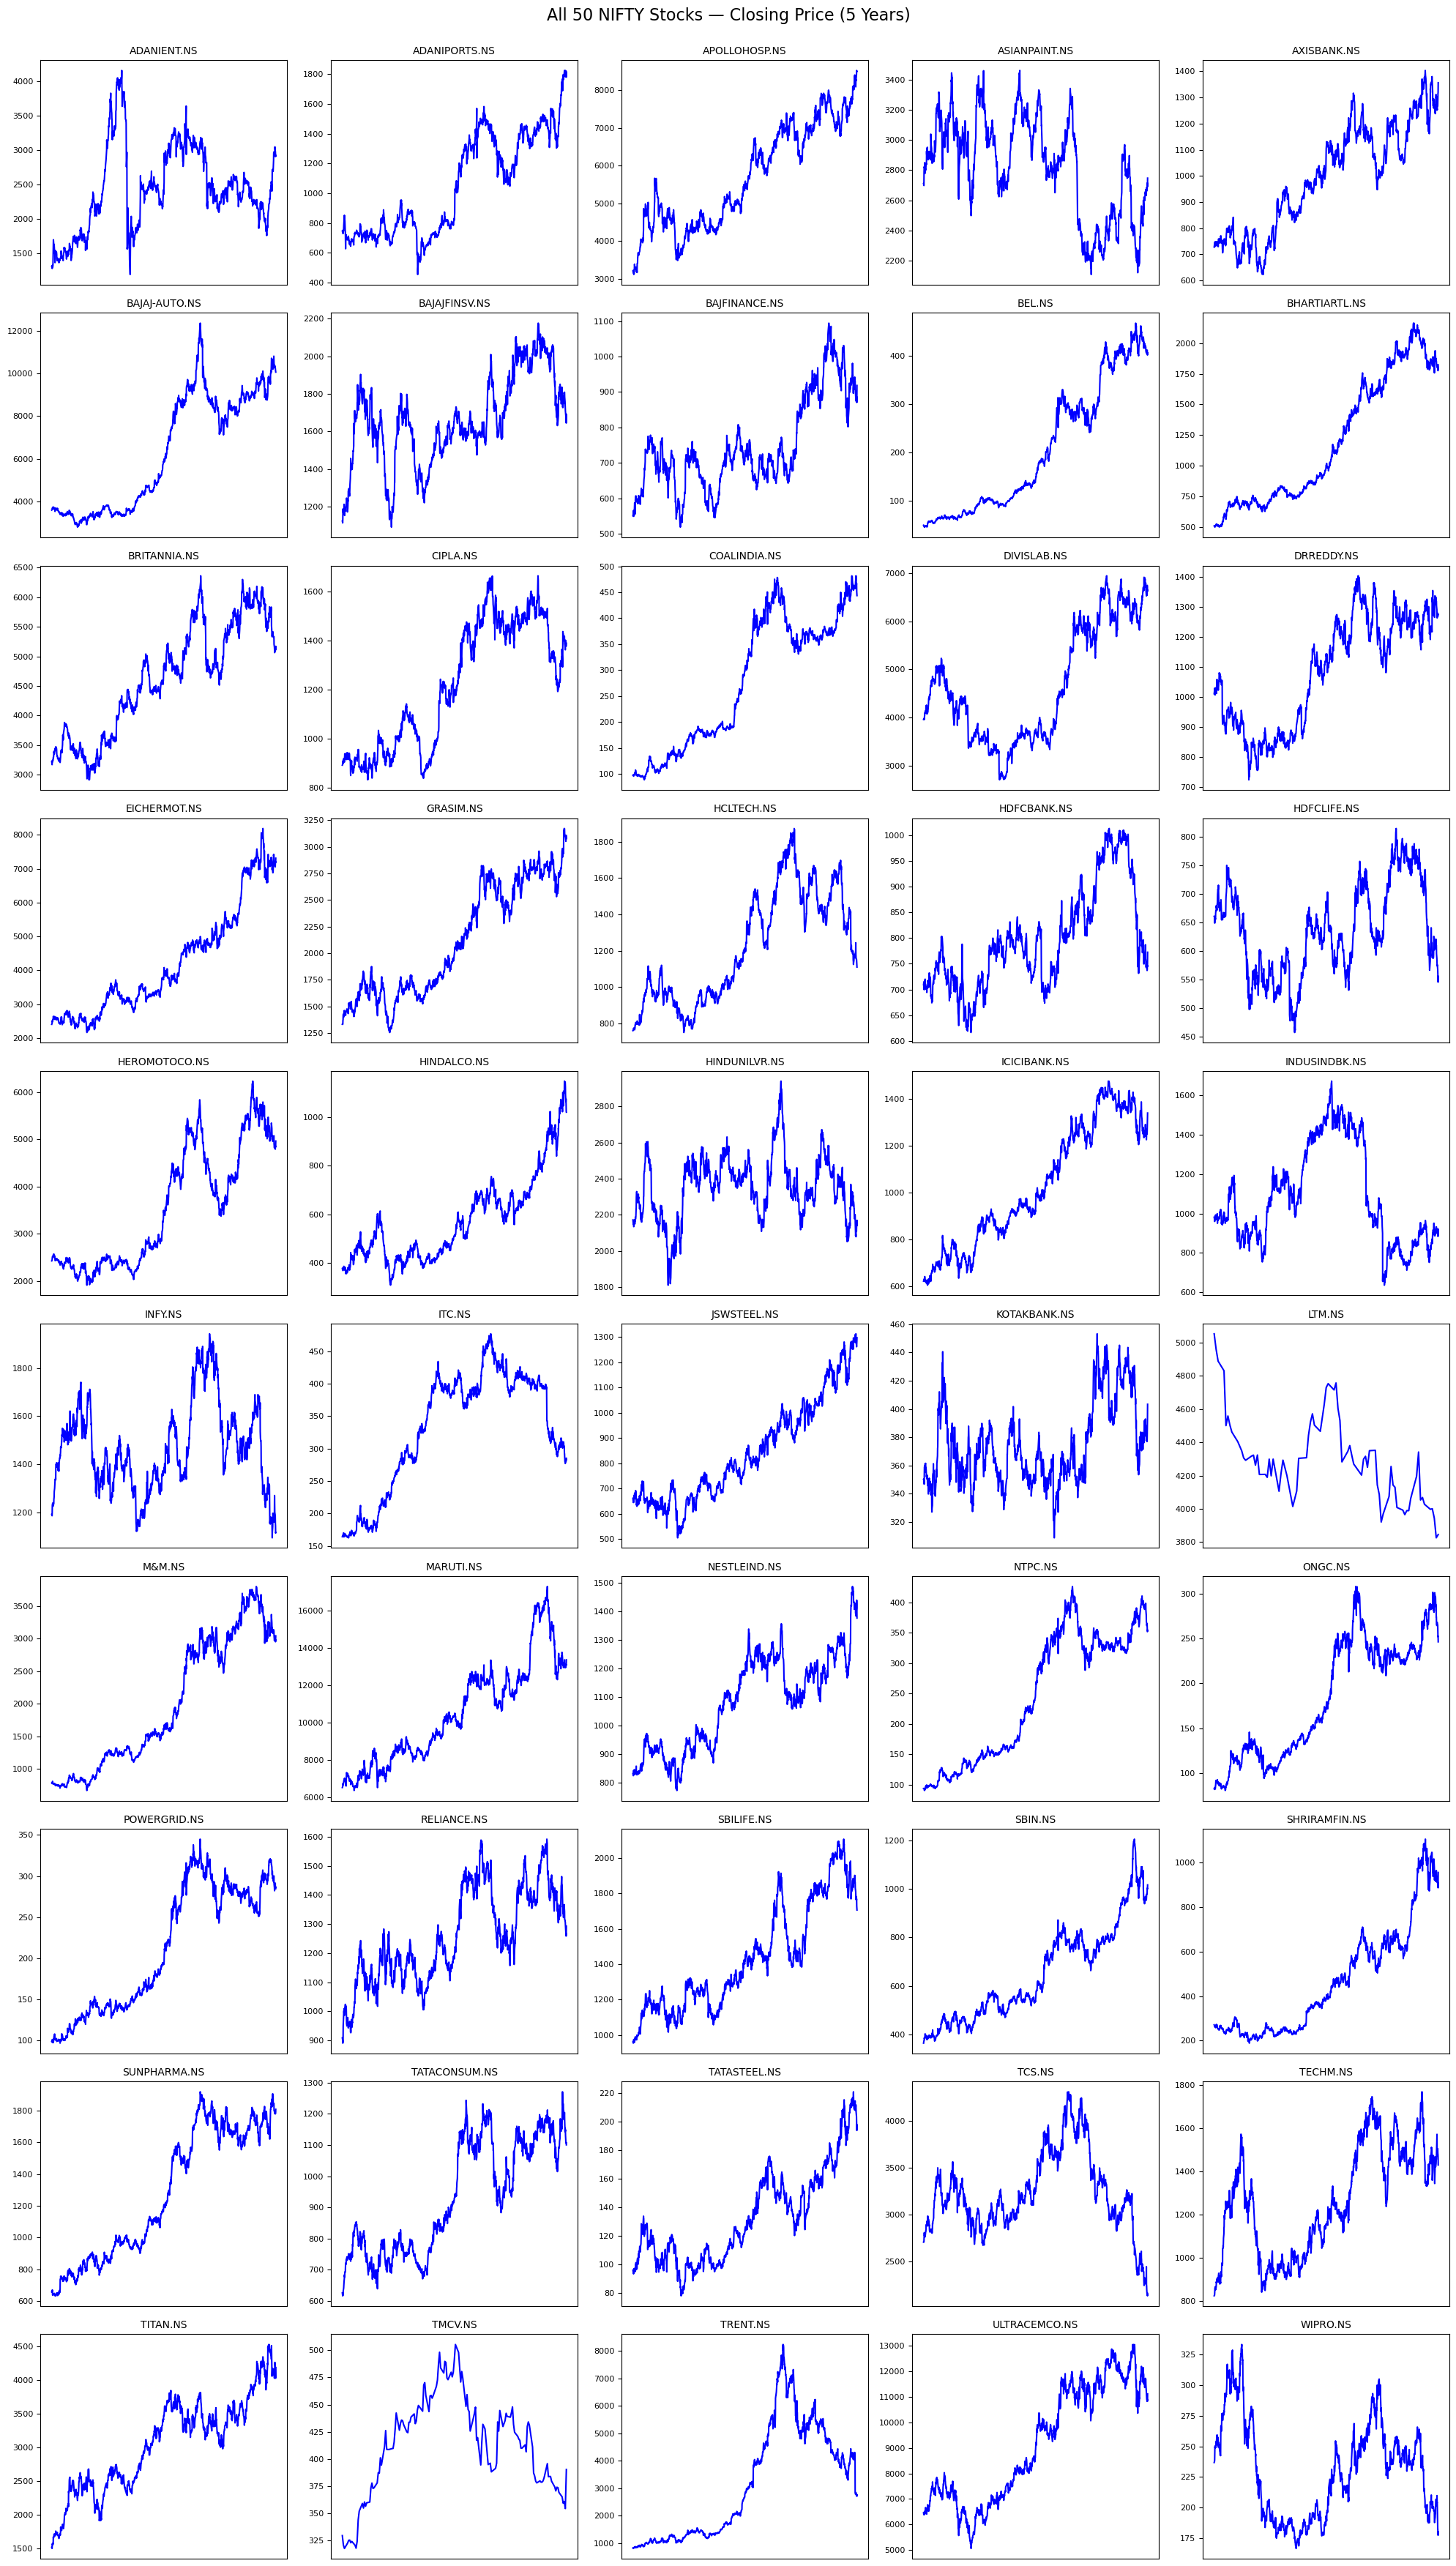

In [24]:
##CHART 3
#Charts of all stocks 

ticker_lst=sorted(df['Ticker'].unique())

fig, axes = plt.subplots(10,5,figsize=(20,35))
axes=axes.flatten()

for i,ticker in enumerate(ticker_lst):
    stock_data=df[df['Ticker']==ticker]
    stock_data=stock_data.sort_values(by='Date',ignore_index=True)
    
    axes[i].plot(stock_data['Date'],stock_data['Close'],color='blue',linewidth=1.5)
    
    axes[i].set_title(ticker,fontsize=10)
    axes[i].set_xticks([])
    axes[i].tick_params(axis='y',labelsize=8)
    
   
plt.suptitle(
    "All 50 NIFTY Stocks — Closing Price (5 Years)",
    fontsize = 16,
    y        = 1.00 )    
plt.tight_layout()        

plt.show()


In [25]:
#CHART 4 
#Daily returns distribution 

#Dropdown menu
dropdown=widgets.Dropdown(
    options=sorted(df['Ticker'].unique()),
    value='TCS.NS',
    description='Select Stock:',
)

def distribution_plot(ticker):
    selected_stock=df[df['Ticker']==ticker]
    returns=selected_stock['daily_return'].dropna()
    company_sel=selected_stock['Company'].iloc[0]

    sns.histplot(data=returns,bins=50,kde=True)

    plt.axvline(x=0,color='red',linestyle='--',linewidth=1.5)

    plt.title(f'{company_sel}-Daily returns distribution')
    plt.xlabel('Daily Return')
    plt.ylabel('Frequency')
    plt.show()

widgets.interactive(distribution_plot,ticker=dropdown)

interactive(children=(Dropdown(description='Select Stock:', index=43, options=('ADANIENT.NS', 'ADANIPORTS.NS',…

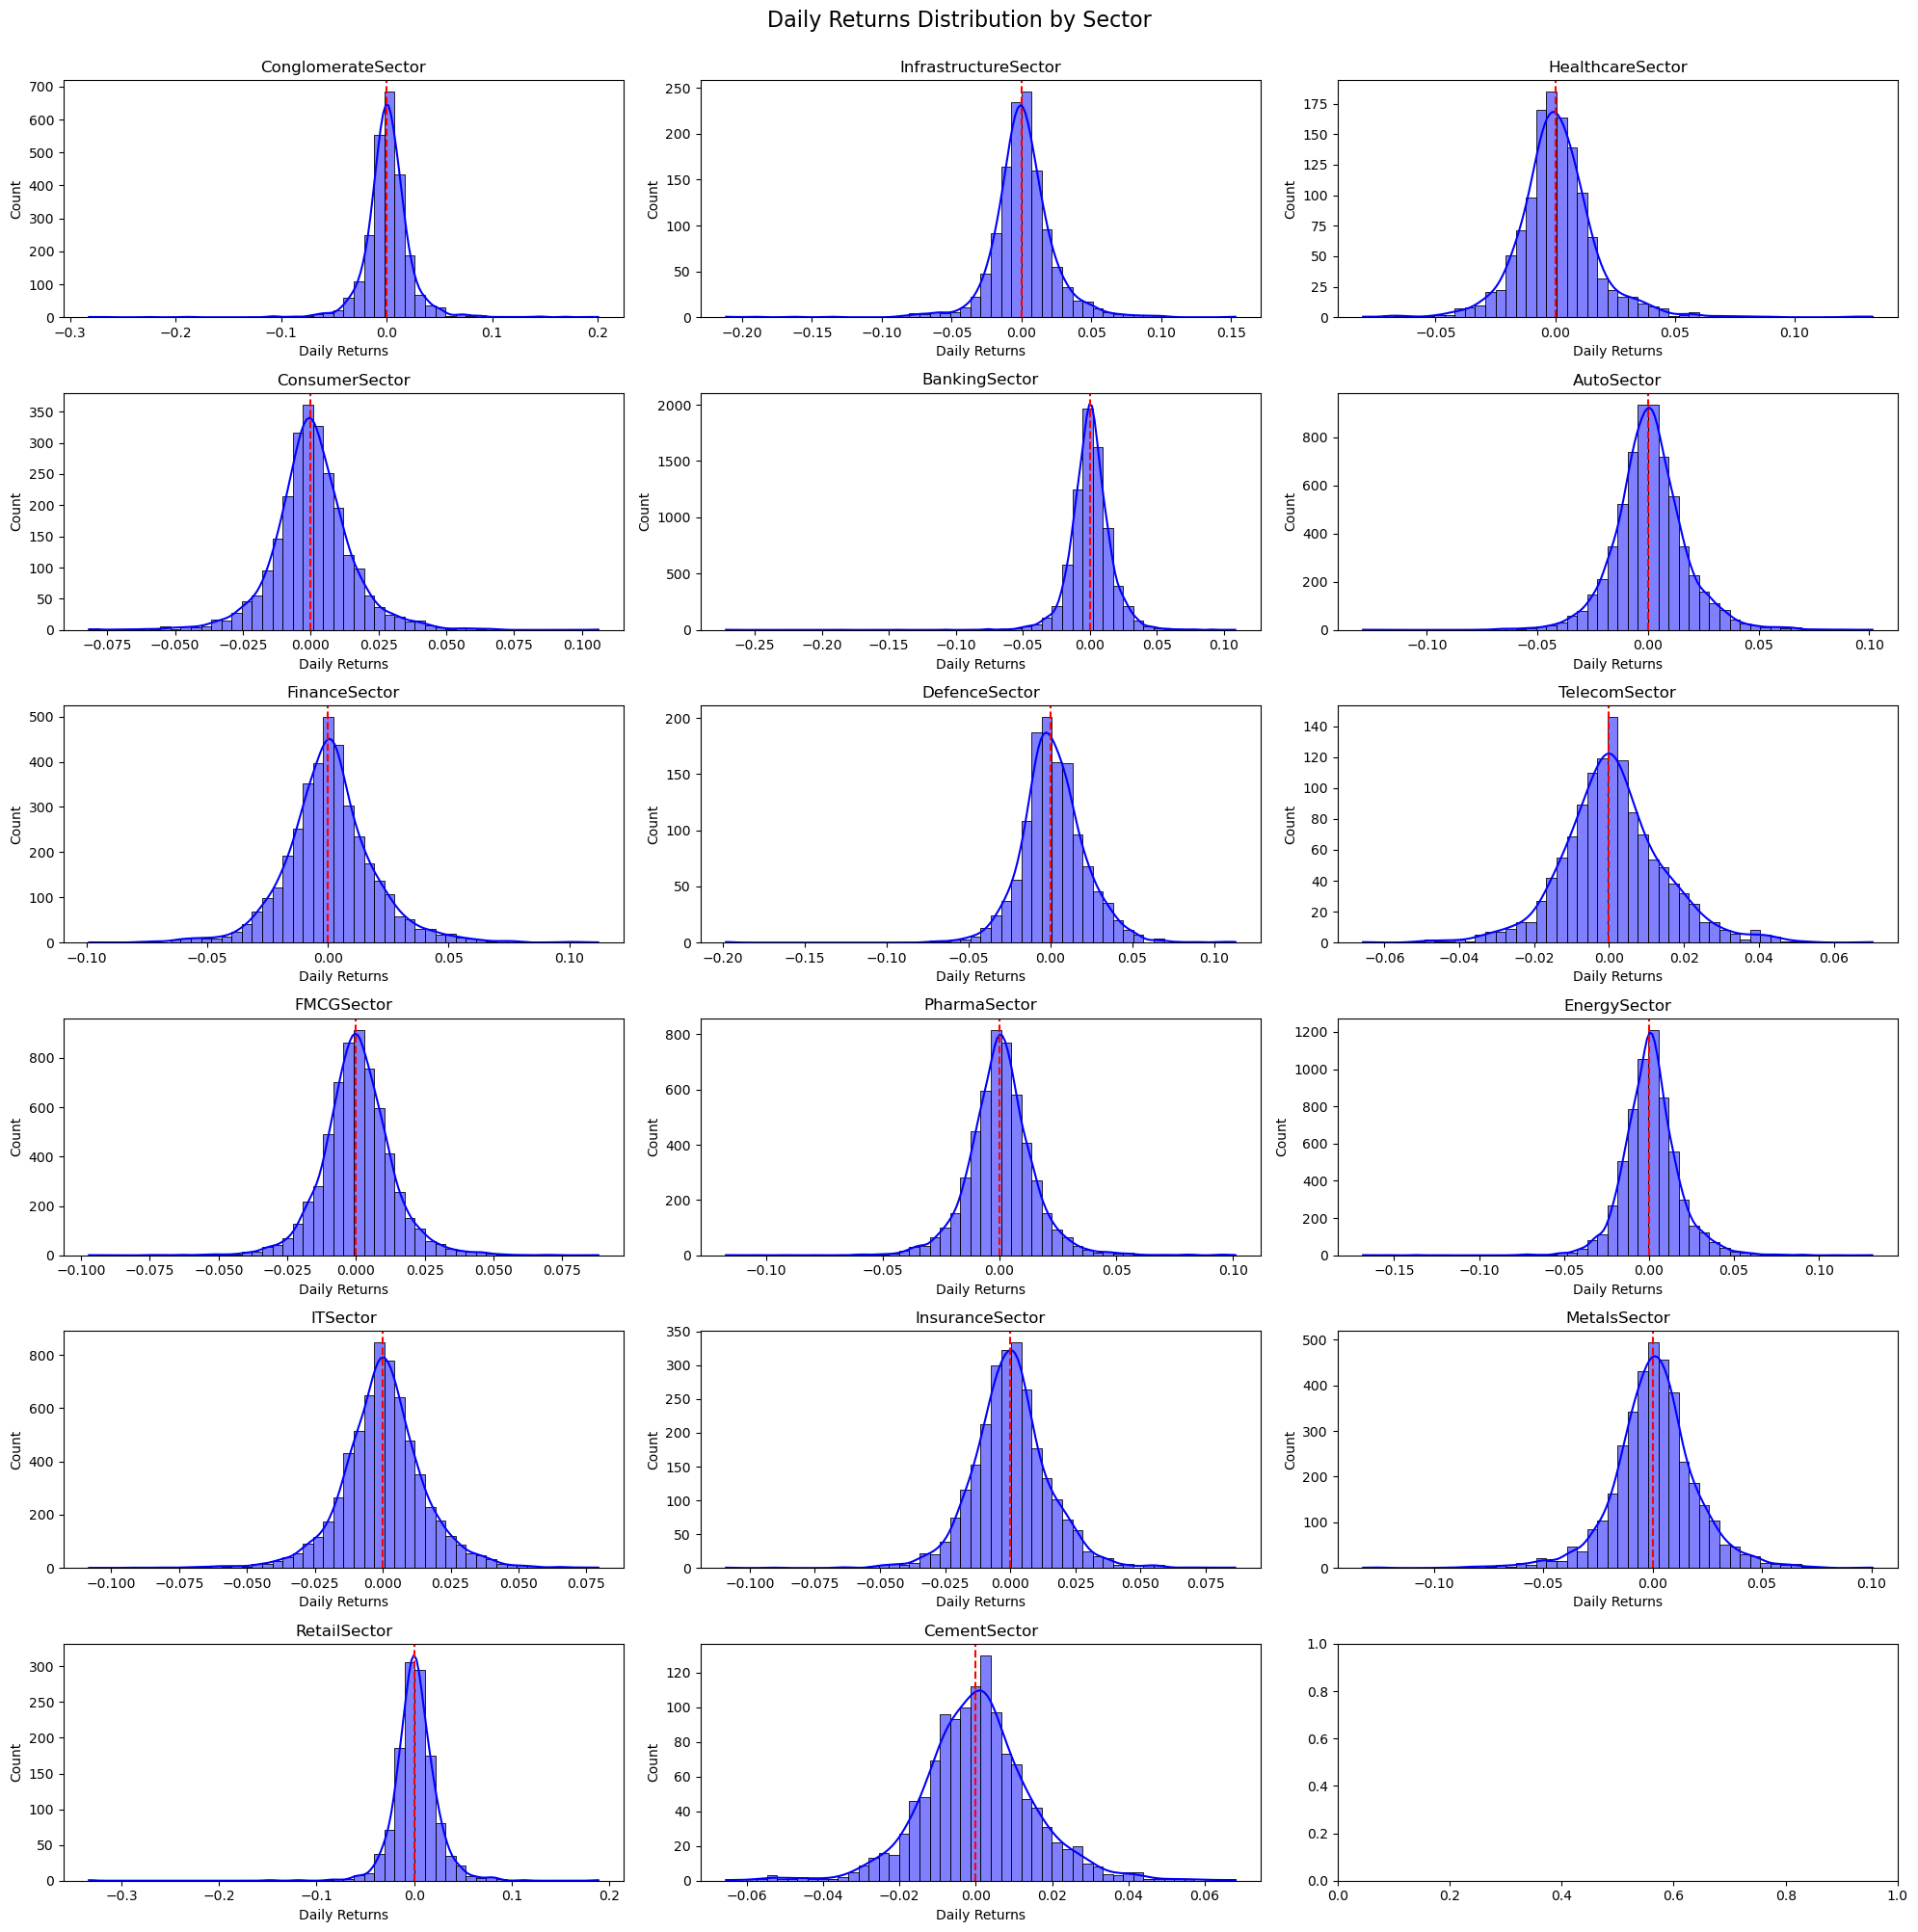

In [26]:
#CHART 5
#comparison of all sectors

sectors=df['Sector'].unique()

n_sector=len(sectors)
n_cols=3
n_rows=n_sector//3+1

fig,axes=plt.subplots(n_rows,n_cols,figsize=(20,20))
axes=axes.flatten()

for i , sector in enumerate(sectors):
    filtered_data=df[df['Sector']==sector]['daily_return'].dropna()

    sns.histplot(data=filtered_data,bins=50,kde=True,color='blue',ax=axes[i])
    axes[i].axvline(x=0,color='red',linestyle='--',linewidth=1.5)

    axes[i].set_title(f'{sector}Sector')
    axes[i].set_xlabel("Daily Returns")

plt.suptitle('Daily Returns Distribution by Sector', fontsize=16,y=1.00)
plt.tight_layout()
plt.show()


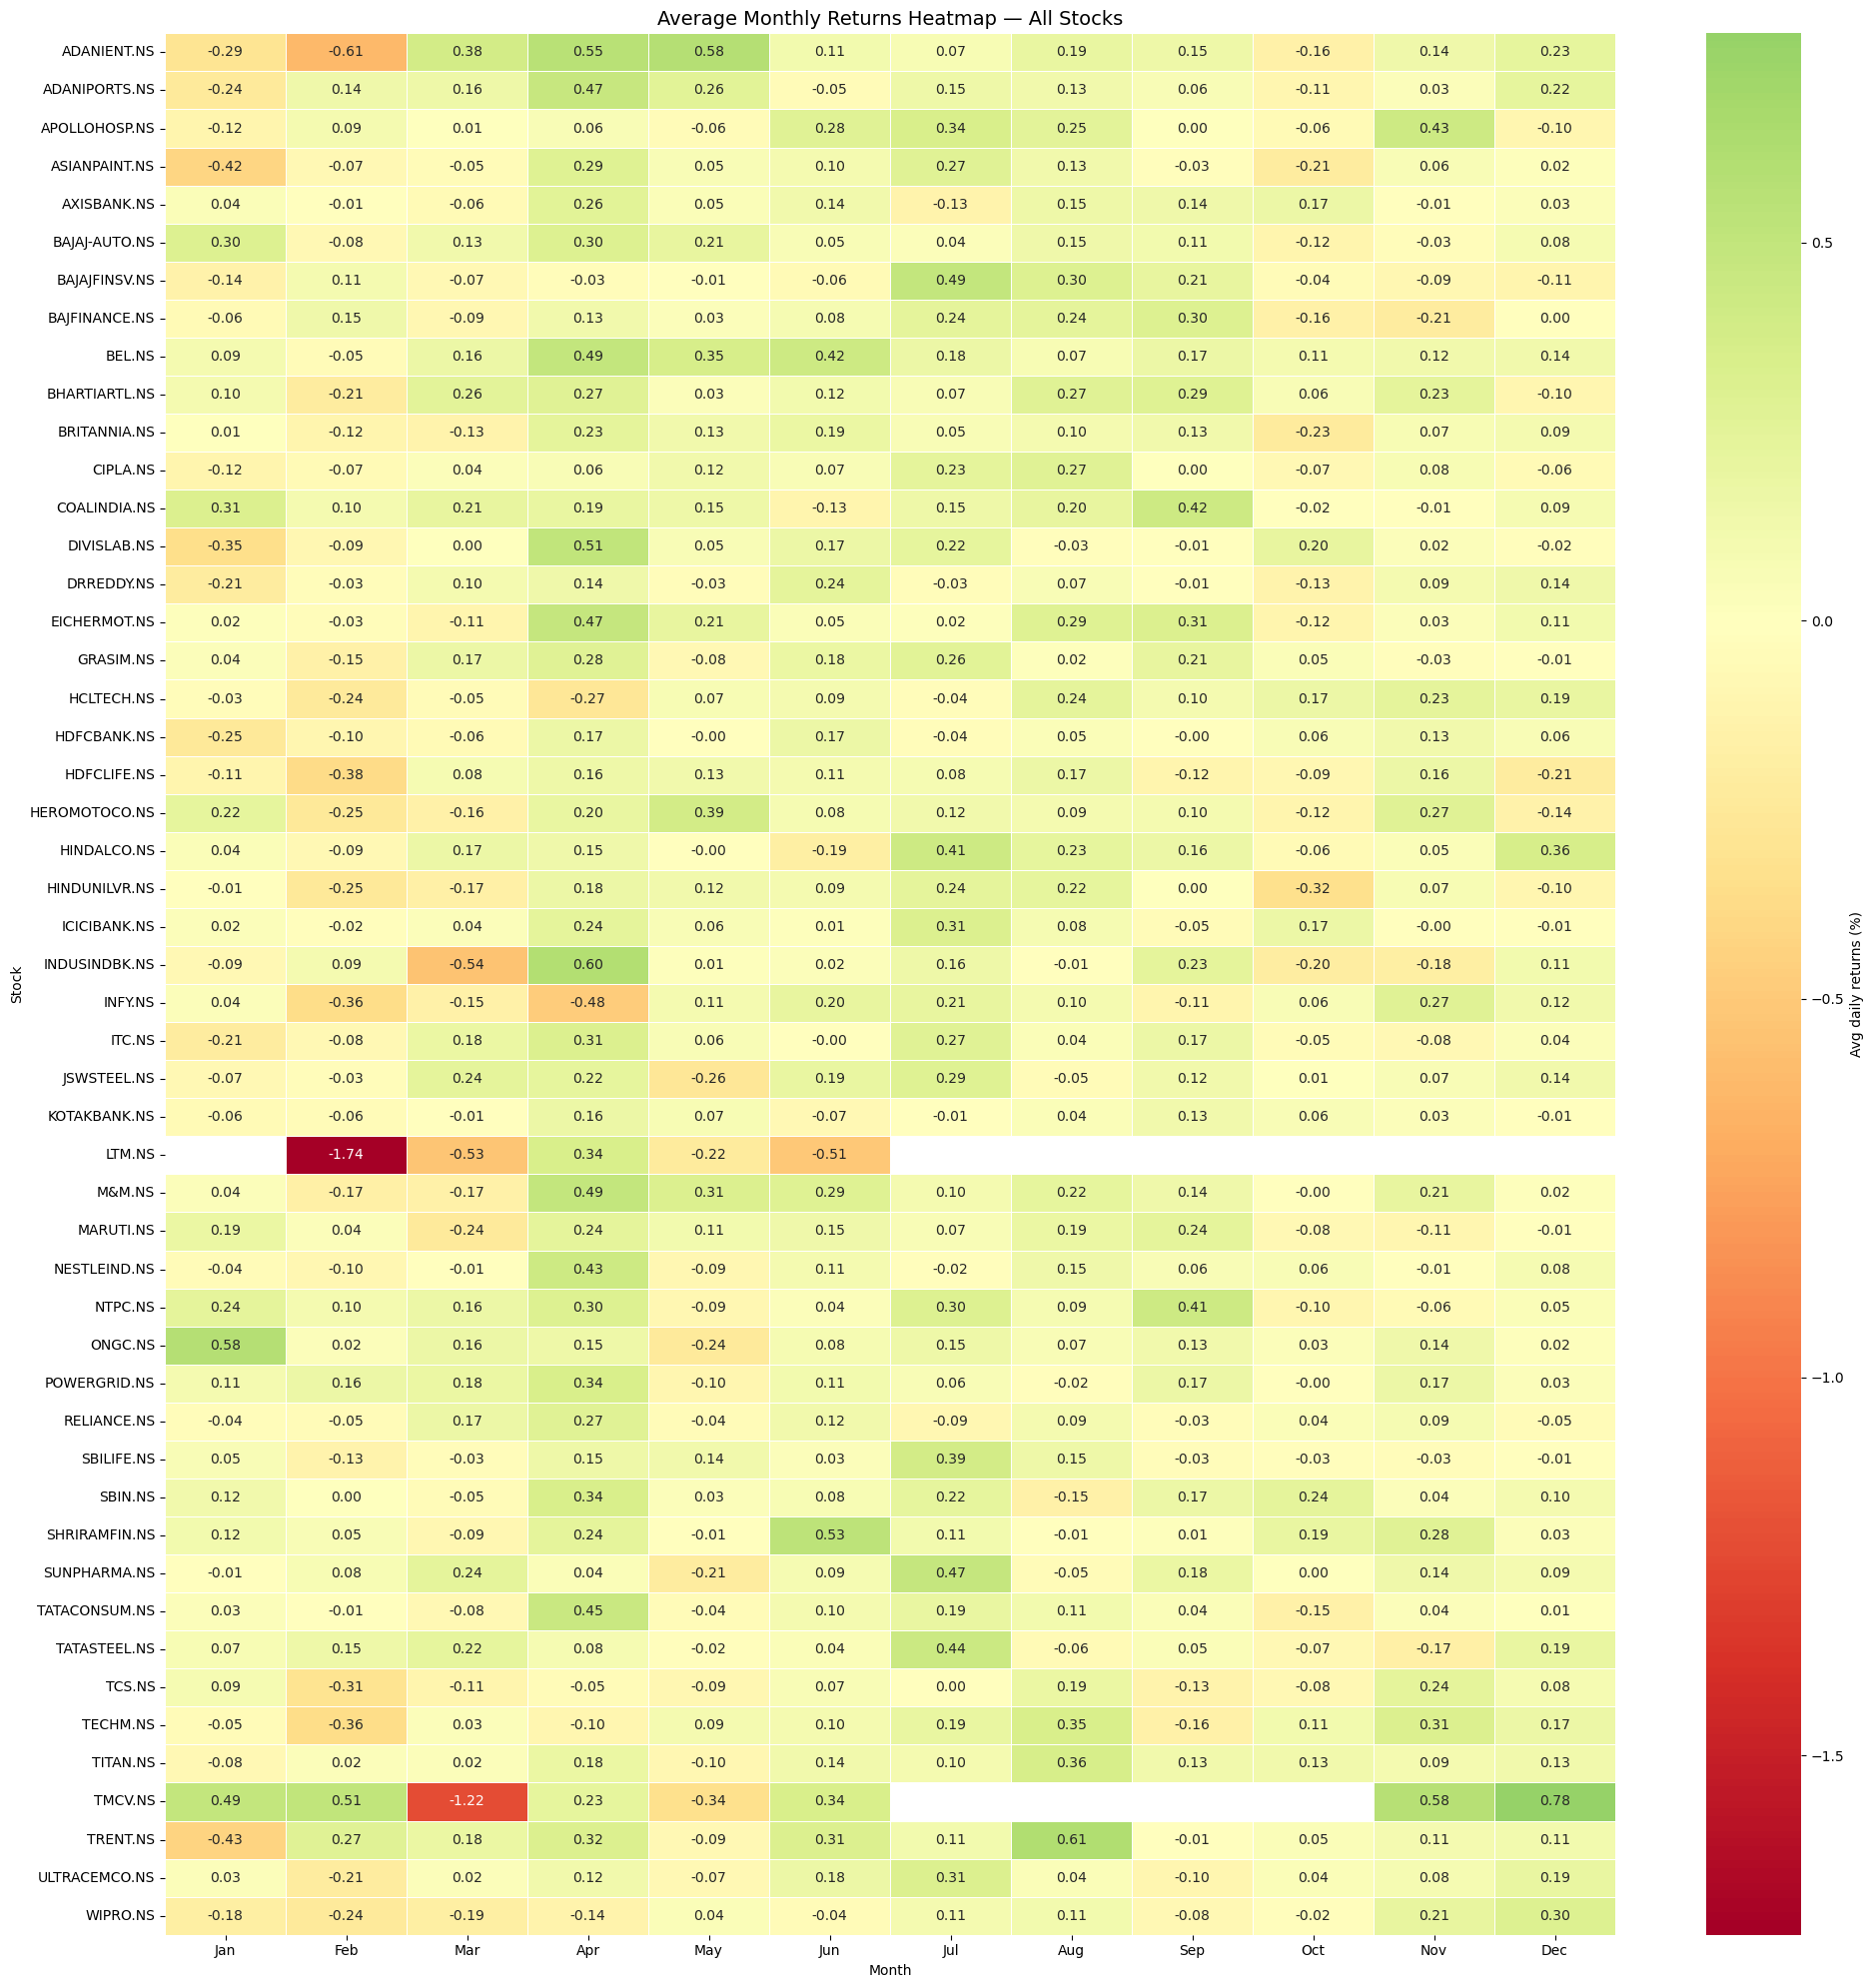

In [27]:
##CHART 6 
#Monthly returns heatmap

monthly_returns=df.groupby(['Ticker','month'])['daily_return'].mean()
monthly_returns=monthly_returns.reset_index()

#pivot table
pivot_table=monthly_returns.pivot(index='Ticker',columns='month',values='daily_return')

month_names = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
    5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
    9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}

pivot_table=pivot_table.rename(columns=month_names)
pivot_table=pivot_table*100

#plot
plt.figure(figsize=(20,20))

sns.heatmap(pivot_table,cmap='RdYlGn',center=0,annot=True,fmt='.2f',linewidths=0.5,cbar_kws={'label':"Avg daily returns (%)",})

plt.title('Average Monthly Returns Heatmap — All Stocks', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Stock')
plt.tight_layout()
plt.show()

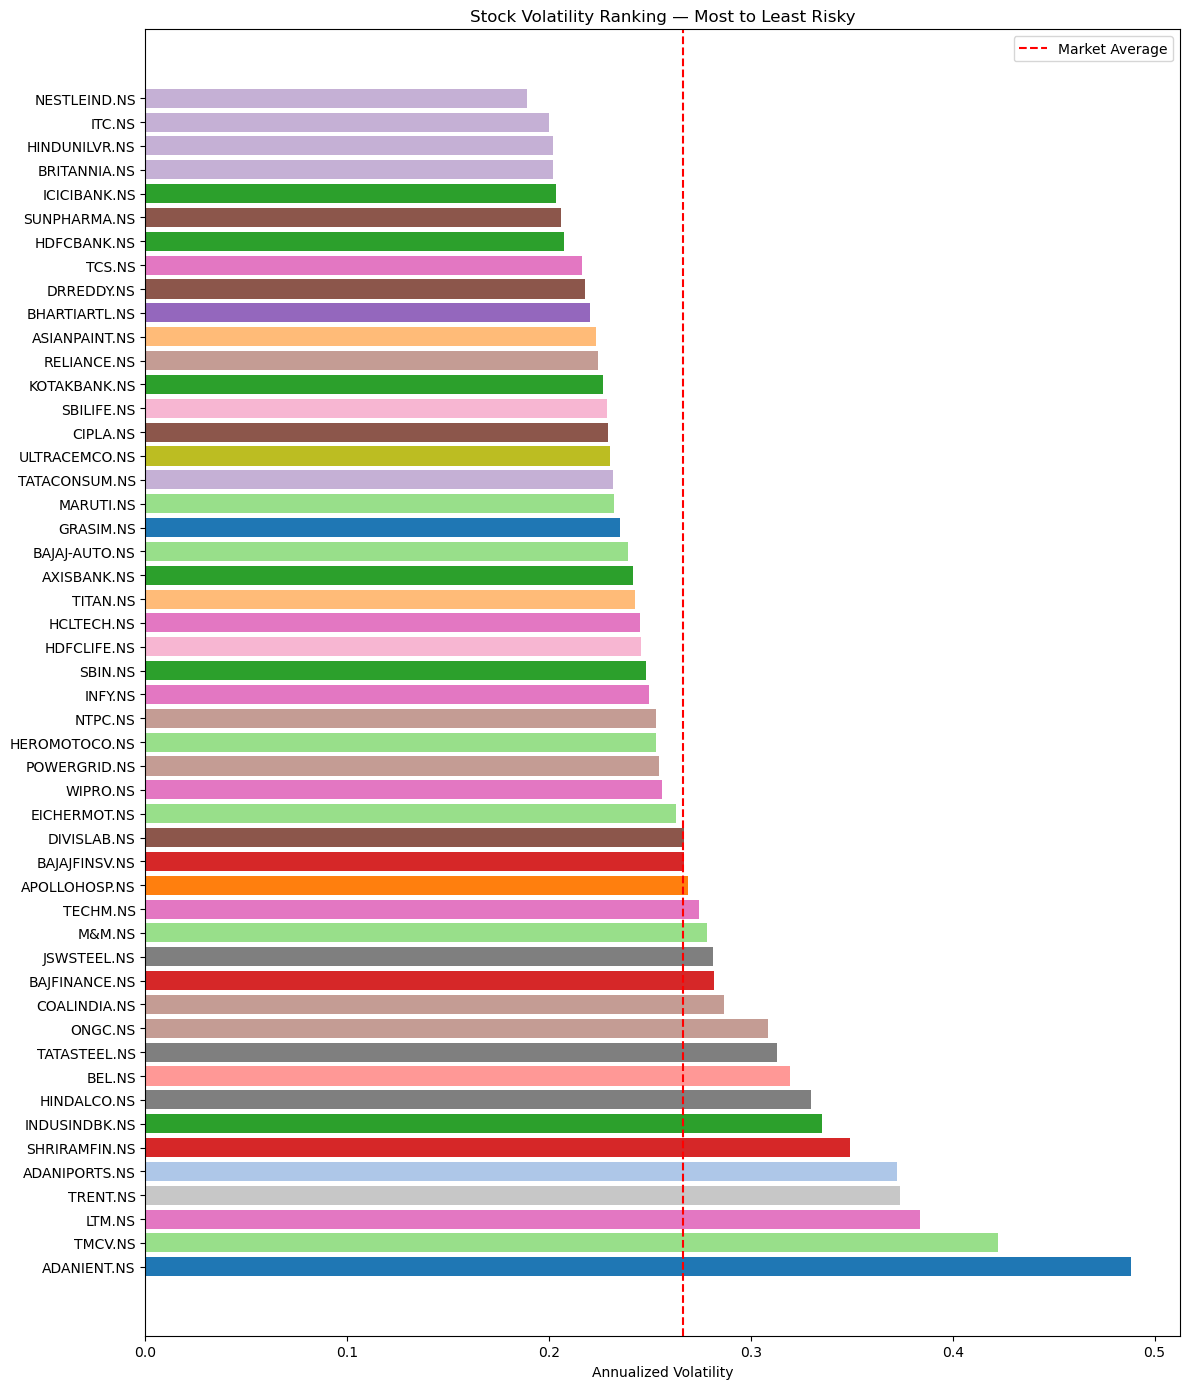

In [ ]:
#CHART 7

vol_df = df.groupby('Ticker')['daily_return'].std() * (252 ** 0.5)
vol_df = vol_df.reset_index()
vol_df.columns = ['Ticker', 'Volatility']
vol_df = vol_df.sort_values('Volatility', ascending=False)

company_sector=df[['Ticker','Company','Sector']].drop_duplicates()

vol_df = vol_df.merge(company_sector,on='Ticker')

palette = sns.color_palette("tab20", n_colors=df['Sector'].nunique())
sector_colors = dict(zip(df['Sector'].unique(), palette))
colors = vol_df['Sector'].map(sector_colors)



plt.figure(figsize=(12, 14))

plt.barh(
    y     = vol_df['Ticker'],
    width = vol_df['Volatility'],
    color = colors
)

plt.xlabel('Annualized Volatility')
plt.title('Stock Volatility Ranking — Most to Least Risky')
plt.axvline(x=vol_df['Volatility'].mean(), 
            color='red', 
            linestyle='--',
            label='Market Average')
plt.legend()
plt.tight_layout()
plt.show()


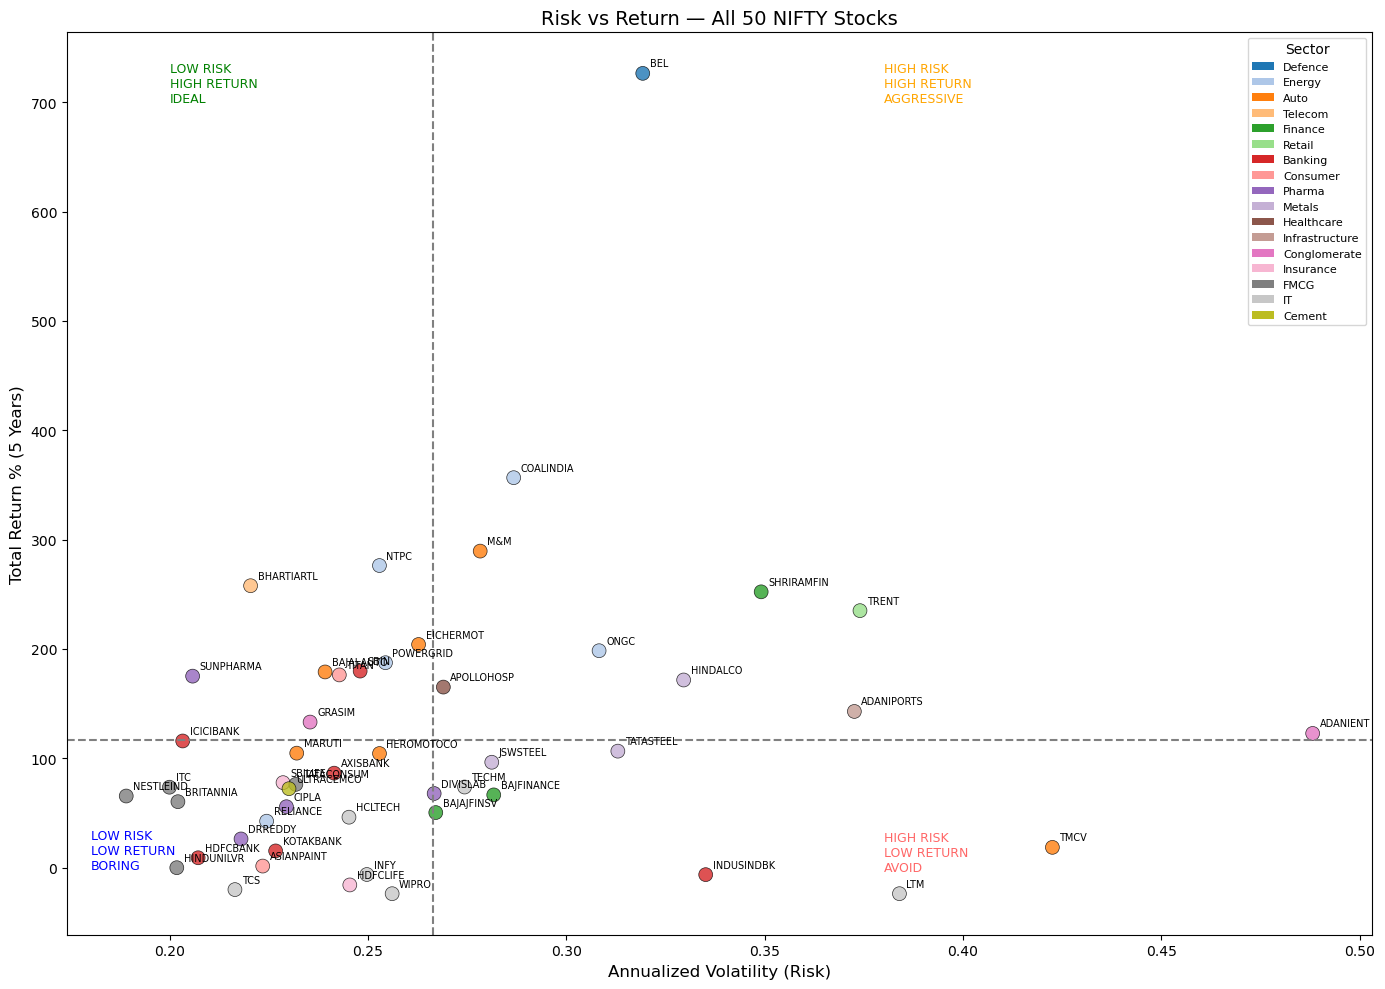

In [29]:
#CHART 8

scatter_df = stock_summary.merge(
    vol_df[['Ticker', 'Volatility', 'Sector']],
    on = 'Ticker'
)

sectors   = scatter_df['Sector'].unique()
palette   = sns.color_palette("tab20", n_colors=len(sectors))
color_map = dict(zip(sectors, palette))
colors    = scatter_df['Sector'].map(color_map)

plt.figure(figsize=(14, 10))

plt.scatter(
    x     = scatter_df['Volatility'],
    y     = scatter_df['Total_return'],
    c     = colors,
    s     = 100,           
    alpha = 0.8,            
    edgecolors = 'black',    
    linewidths = 0.5
)

for i, row in scatter_df.iterrows():
    plt.annotate(
        text = row['Ticker'].replace('.NS', ''),  
        xy   = (row['Volatility'], row['Total_return']),
        xytext = (5, 5),             
        textcoords = 'offset points',
        fontsize = 7
    )

avg_vol    = scatter_df['Volatility'].mean()
avg_return = scatter_df['Total_return'].mean()

# Vertical line at average volatility
plt.axvline(x=avg_vol, color='gray', linestyle='--')

# Horizontal line at average return
plt.axhline(y=avg_return, color='gray', linestyle='--')

plt.text(0.20, 700, 'LOW RISK\nHIGH RETURN\nIDEAL',
         fontsize=9, color='green')

plt.text(0.38, 700, 'HIGH RISK\nHIGH RETURN\nAGGRESSIVE',
         fontsize=9, color='orange')

plt.text(0.18, -1, 'LOW RISK\nLOW RETURN\nBORING',
         fontsize=9, color='blue')

plt.text(0.38, -3, 'HIGH RISK\nLOW RETURN\nAVOID',
         fontsize=9, color='red', alpha=0.6)


legend_elements = [
    Patch(facecolor=color_map[sector], label=sector)
    for sector in sectors
]

plt.legend(
    handles  = legend_elements,
    loc      = 'upper right',
    fontsize = 8,
    title    = 'Sector'
)

plt.title('Risk vs Return — All 50 NIFTY Stocks', fontsize=14)
plt.xlabel('Annualized Volatility (Risk)', fontsize=12)
plt.ylabel('Total Return % (5 Years)', fontsize=12)
plt.tight_layout()
plt.show()

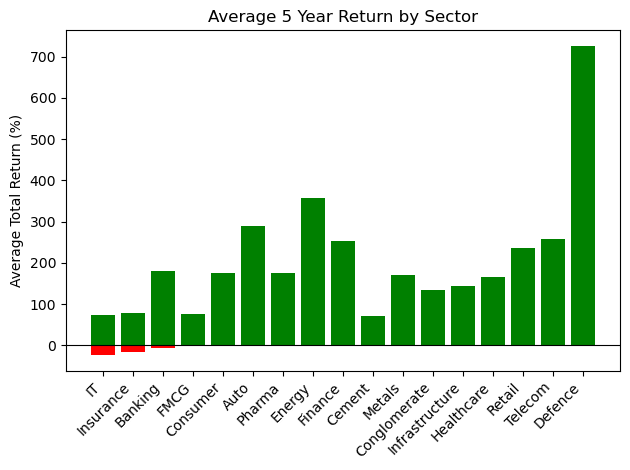

In [30]:
#CHART 9

sector_df=stock_summary.merge(vol_df[['Ticker','Sector']],on='Ticker')

sector_returns=sector_df.groupby(['Ticker','Sector'])['Total_return'].mean()
sector_returns=sector_returns.sort_values(ascending=True).reset_index()

colors = ['green' if x > 0 else 'red' for x in sector_returns['Total_return']]

plt.bar(sector_returns['Sector'],sector_returns['Total_return'],color=colors,)

plt.axhline(y=0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.title('Average 5 Year Return by Sector')
plt.ylabel('Average Total Return (%)')
plt.tight_layout()
plt.show()


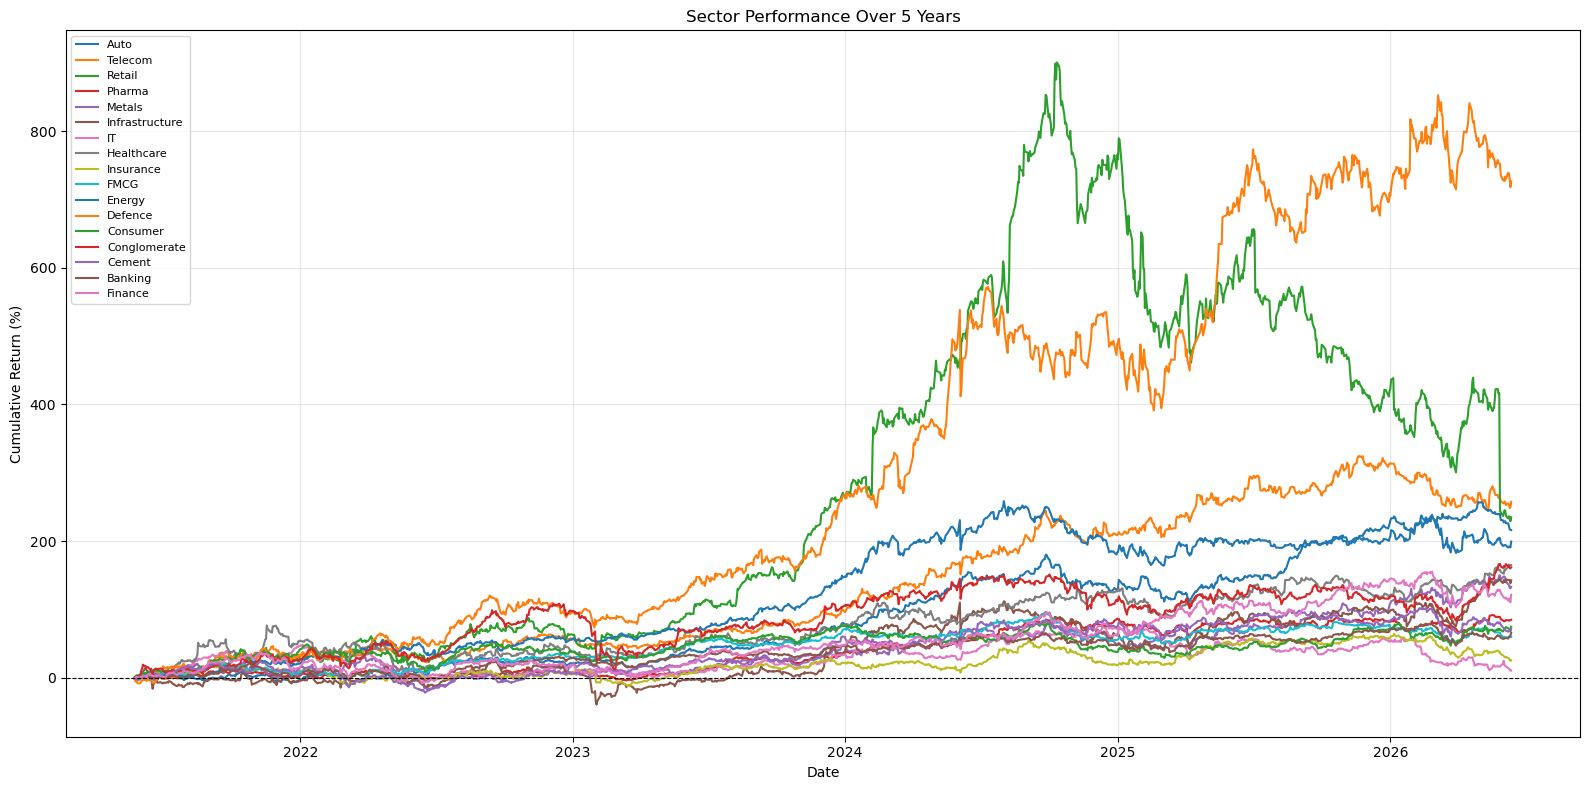

In [31]:
#CHART 9

sector_daily=df.groupby(['Date','Sector'])['daily_return'].mean()
sector_daily=sector_daily.reset_index().sort_values(by='Date')

for sector in sectors:
  Daily_return=sector_daily[sector_daily['Sector']==sector]['daily_return']
  cum_return= (1 + Daily_return).cumprod() - 1 *100

sector_daily['Cumulative_Return'] = sector_daily.groupby('Sector')['daily_return'].transform(lambda x: (1 + x).cumprod() - 1) * 100

plt.figure(figsize=(16, 8))

for sector in sector_daily['Sector'].unique():
    sector_data = sector_daily[sector_daily['Sector'] == sector]

    plt.plot(sector_data['Date'],sector_data['Cumulative_Return'],label = sector,linewidth = 1.5)

plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

plt.title('Sector Performance Over 5 Years')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend(loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

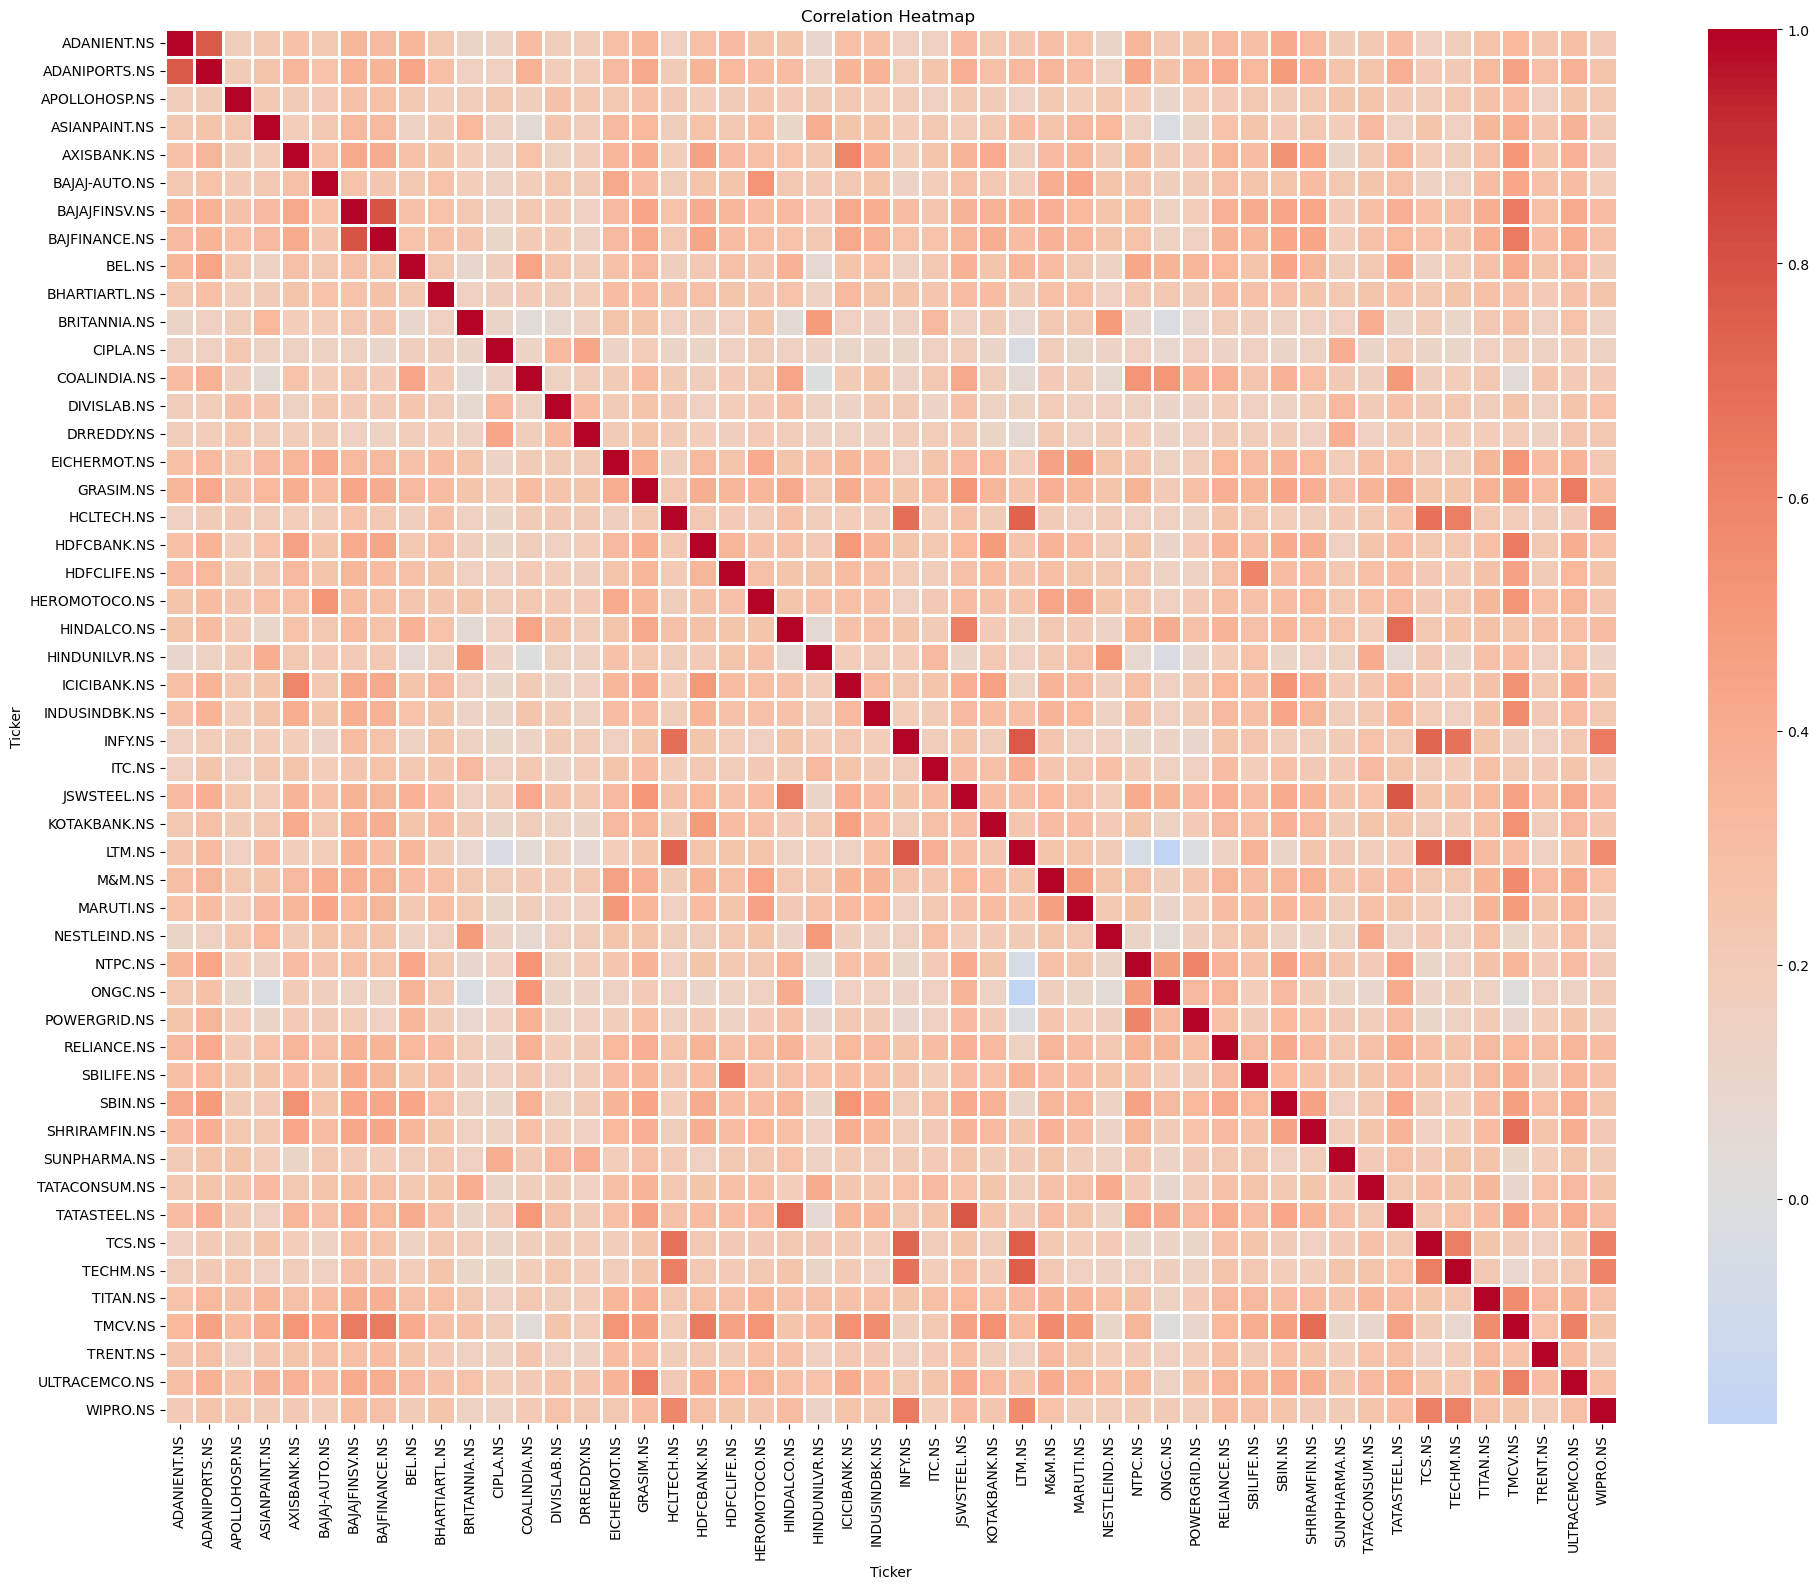

In [32]:
#CHART 10

main_pivot=df.pivot_table(index='Date',columns='Ticker',values='daily_return')
corr_pivot=main_pivot.corr()

plt.figure(figsize=(20,16))
sns.heatmap(data=corr_pivot,cmap='coolwarm',center=0,annot=False,linewidth=1.0,cbar=True)

plt.title("Correlation Heatmap ")
plt.tight_layout()
plt.show()